In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [ ]:
df = pd.read_csv("Predictive_Sales_Forecast.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,06-01-2020,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,06-01-2020,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,06-01-2020,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,06-01-2020,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,06-01-2020,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4384, 10)


In [ ]:
df.isnull().sum()

,0
Date,0
Product Name,0
Category,0
Units Sold,0
Price,0
Revenue,0
Discount,0
Units Returned,0
Location,0
Platform,0


In [ ]:
df.head(10)

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,06-01-2020,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,06-01-2020,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,06-01-2020,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,06-01-2020,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,06-01-2020,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
5,06-01-2020,BCAA,Amino Acid,154,41.19,6343.26,0.13,1,UK,Walmart
6,06-01-2020,Creatine,Performance,134,32.49,4353.66,0.05,1,UK,Walmart
7,06-01-2020,Zinc,Mineral,147,46.68,6861.96,0.19,0,Canada,Amazon
8,06-01-2020,Collagen Peptides,Protein,147,10.96,1611.12,0.06,2,USA,Amazon
9,06-01-2020,Magnesium,Mineral,134,20.76,2781.84,0.00,0,Canada,Amazon


In [ ]:
df.tail(10)

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
4374,31-03-2025,Creatine,Performance,174,35.63,6199.62,0.03,0,Canada,Amazon
4375,31-03-2025,Zinc,Mineral,147,23.47,3450.09,0.14,1,Canada,Walmart
4376,31-03-2025,Collagen Peptides,Protein,146,52.79,7707.34,0.13,1,USA,Amazon
4377,31-03-2025,Magnesium,Mineral,138,28.45,3926.10,0.25,1,UK,Walmart
4378,31-03-2025,Ashwagandha,Herbal,145,58.08,8421.60,0.24,2,Canada,Amazon
4379,31-03-2025,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,31-03-2025,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,31-03-2025,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,31-03-2025,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon
4383,31-03-2025,Electrolyte Powder,Hydration,178,39.12,6963.36,0.23,0,UK,iHerb


In [ ]:
df.describe()

,Units Sold,Price,Revenue,Discount,Units Returned
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,150.200274,34.781229,5226.569446,0.124398,1.531478
std,12.396099,14.198309,2192.491946,0.071792,1.258479
min,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,158.000000,46.712500,7009.960000,0.190000,2.000000
max,194.000000,59.970000,10761.850000,0.250000,8.000000


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [ ]:
print(df.dtypes)

Date               object
Product Name       object
Category           object
Units Sold          int64
Price             float64
Revenue           float64
Discount          float64
Units Returned      int64
Location           object
Platform           object
dtype: object


In [ ]:
print(df.columns)

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Date Converted Successfully")
df.head()

Date Converted Successfully


,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Year,Month,Day
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,2020,1,6
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,2020,1,6
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,2020,1,6
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,2020,1,6
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,2020,1,6


In [ ]:
print("Products:", df['Product Name'].nunique())
print("Categories:", df['Category'].nunique())
print("Locations:", df['Location'].nunique())
print("Platforms:", df['Platform'].nunique())

Products: 16
Categories: 10
Locations: 3
Platforms: 3


In [ ]:
df.describe(include='all')

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Year,Month,Day
count,4384,4384,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384,4384,4384.000000,4384.000000,4384.000000
unique,NaN,16,10,NaN,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,Whey Protein,Vitamin,NaN,NaN,NaN,NaN,NaN,Canada,iHerb,NaN,NaN,NaN
freq,NaN,274,822,NaN,NaN,NaN,NaN,NaN,1507,1499,NaN,NaN,NaN
mean,2022-08-18 12:00:00,NaN,NaN,150.200274,34.781229,5226.569446,0.124398,1.531478,NaN,NaN,2022.149635,6.284672,15.751825
min,2020-01-06 00:00:00,NaN,NaN,103.000000,10.000000,1284.000000,0.000000,0.000000,NaN,NaN,2020.000000,1.000000,1.000000
25%,2021-04-26 00:00:00,NaN,NaN,142.000000,22.597500,3349.372500,0.060000,1.000000,NaN,NaN,2021.000000,3.000000,8.000000
50%,2022-08-18 12:00:00,NaN,NaN,150.000000,34.720000,5173.140000,0.120000,1.000000,NaN,NaN,2022.000000,6.000000,16.000000
75%,2023-12-11 00:00:00,NaN,NaN,158.000000,46.712500,7009.960000,0.190000,2.000000,NaN,NaN,2023.000000,9.000000,23.000000
max,2025-03-31 00:00:00,NaN,NaN,194.000000,59.970000,10761.850000,0.250000,8.000000,NaN,NaN,2025.000000,12.000000,31.000000


In [ ]:
print("Total Revenue:", df['Revenue'].sum())

Total Revenue: 22913280.45


In [ ]:
print("Total Units Sold:", df['Units Sold'].sum())

Total Units Sold: 658478


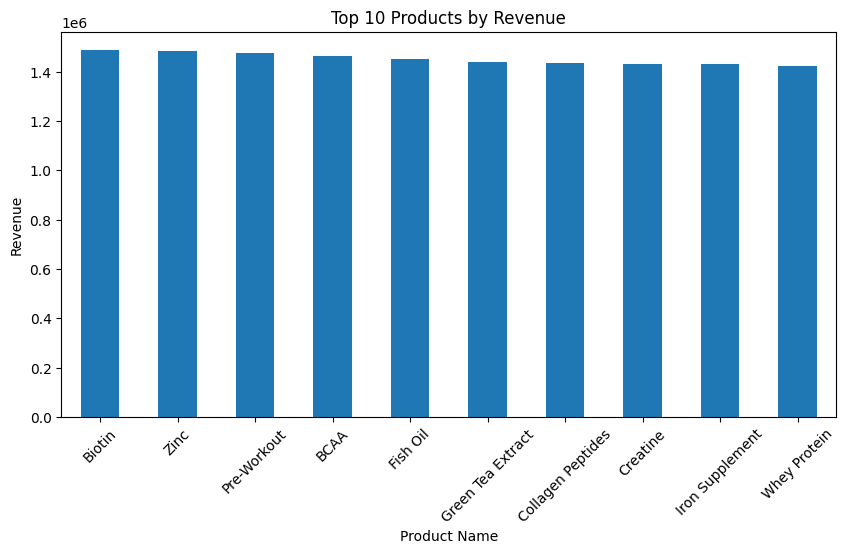

In [ ]:
top_products = df.groupby('Product Name')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

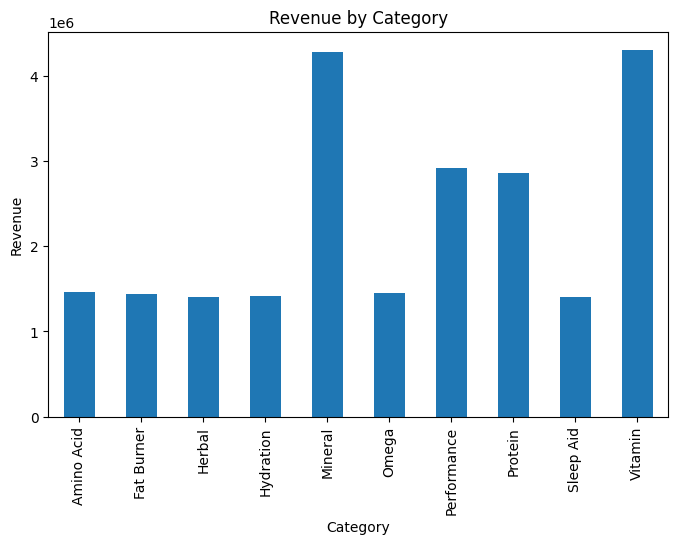

In [ ]:
category_sales = df.groupby('Category')['Revenue'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

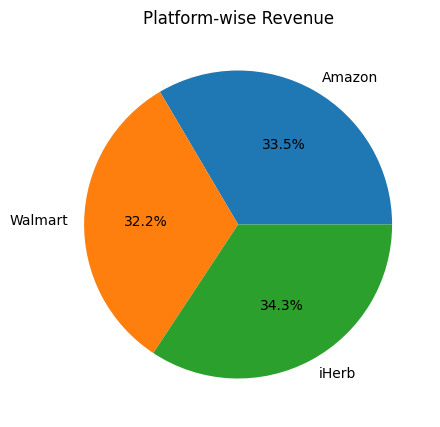

In [ ]:
platform_sales = df.groupby('Platform')['Revenue'].sum()

plt.figure(figsize=(6,5))
platform_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Platform-wise Revenue")
plt.ylabel("")
plt.show()

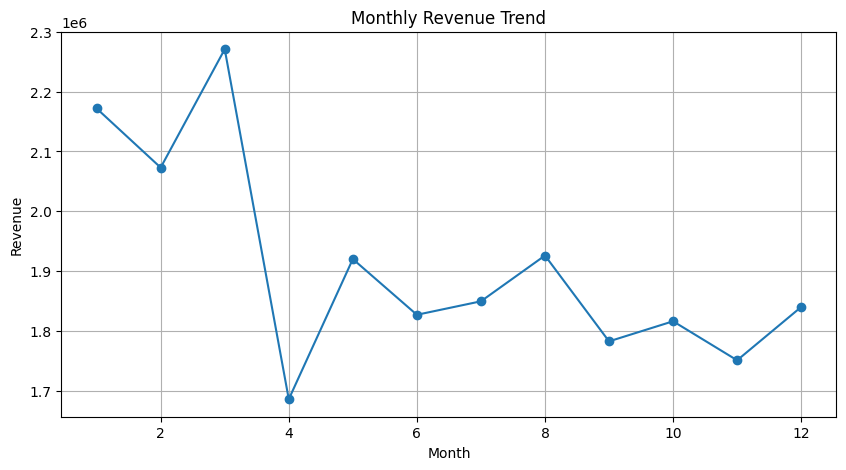

In [ ]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

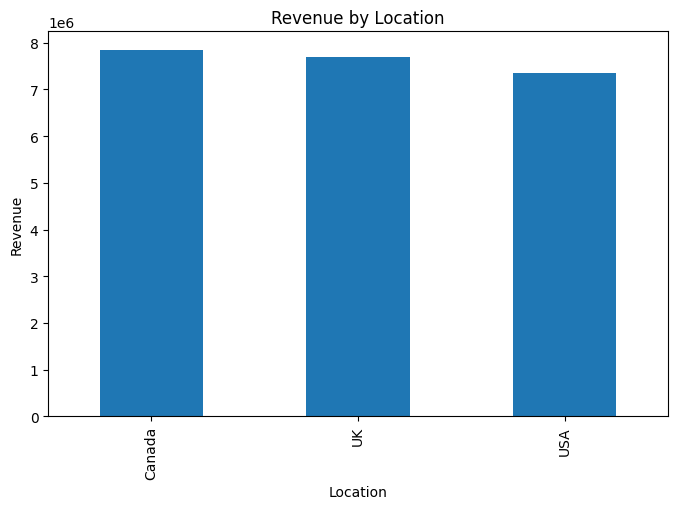

In [ ]:
location_sales = df.groupby('Location')['Revenue'].sum()

plt.figure(figsize=(8,5))
location_sales.plot(kind='bar')
plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")
plt.show()

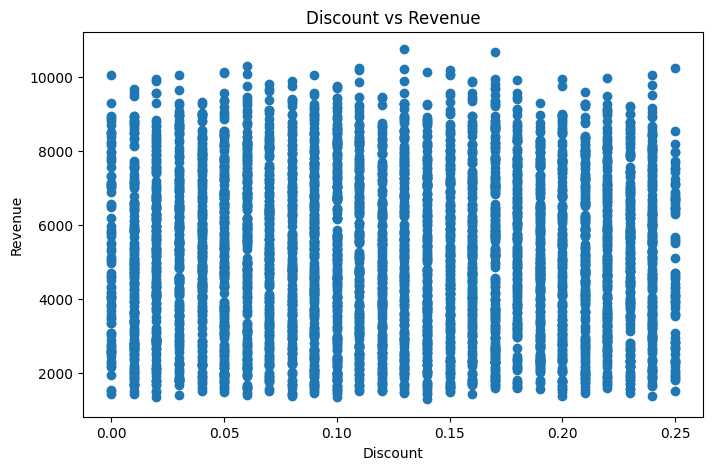

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Revenue'])
plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.show()

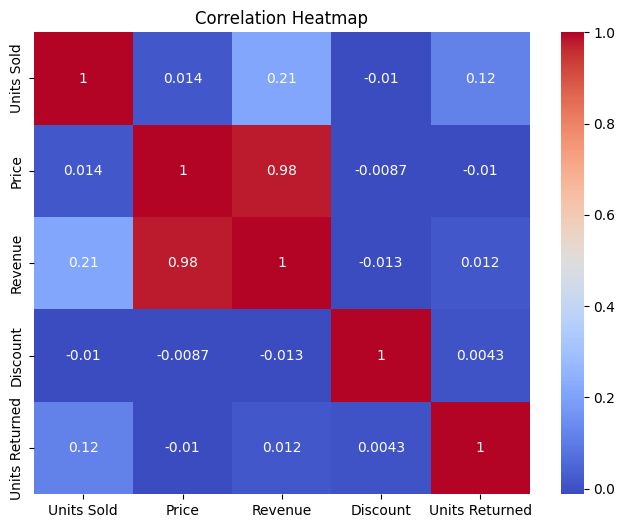

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Units Sold','Price','Revenue','Discount','Units Returned']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X = df[['Units Sold', 'Price', 'Discount', 'Units Returned']]
y = df['Revenue']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3507, 4)
(877, 4)


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[6207.63593946 7834.77214403 7869.33796993 8666.31032972 4999.61440489
 2786.55839591 8100.07457545 8036.47802473 4621.17653147 5013.52240474]


In [ ]:
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 117.98803424061053
MSE : 28869.01113362904
RMSE : 169.90883182939325
R2 Score : 0.9937503343724287


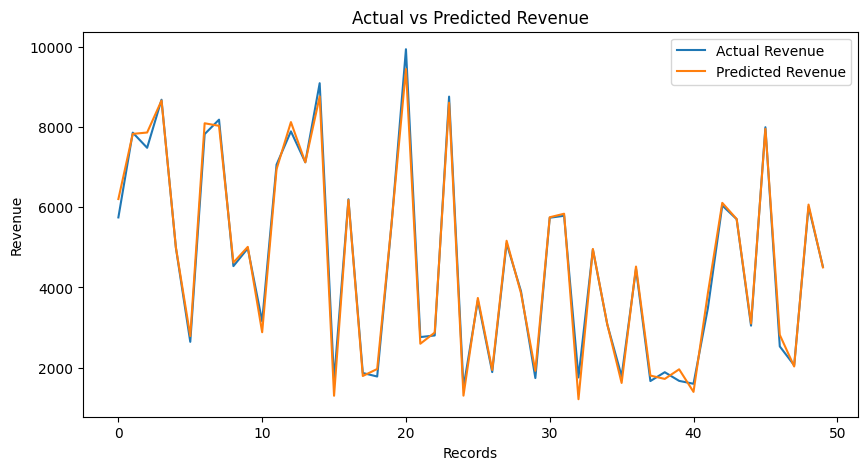

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual Revenue")
plt.plot(y_pred[:50], label="Predicted Revenue")

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Records")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 27.228004446978005
RMSE : 53.25955823134707
R2 Score : 0.9993859270122778


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

          Feature  Importance
1           Price    0.957046
0      Units Sold    0.042694
2        Discount    0.000173
3  Units Returned    0.000088


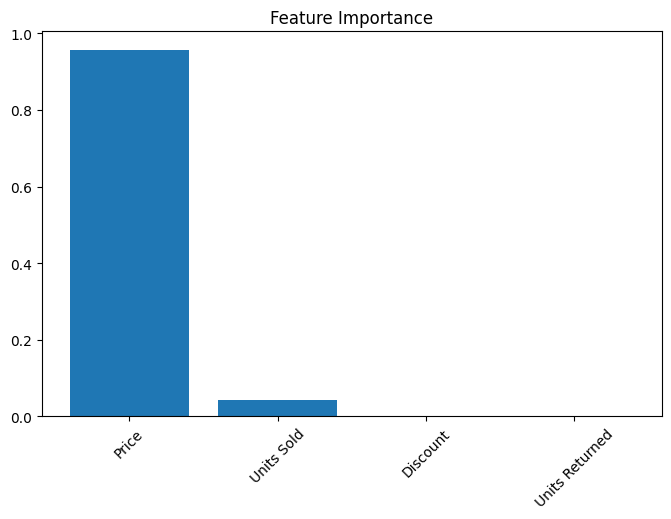

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

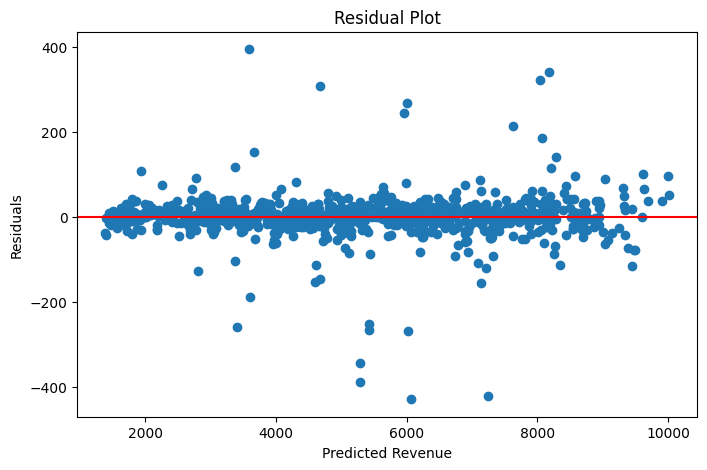

In [ ]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

plt.scatter(rf_pred, residuals)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": rf_pred
})

comparison.head(10)

,Actual Revenue,Predicted Revenue
0,5748.96,6018.2219
1,7866.00,7904.9705
2,7487.90,7501.7492
3,8688.32,8688.9126
4,4990.55,4990.5414
5,2641.76,2659.6462
6,7830.12,7824.6048
7,8190.40,8174.6885
8,4532.76,4524.3410
9,4976.76,4973.2603


**Analysis**

Performed data cleaning and preprocessing on the sales dataset.
Conducted Exploratory Data Analysis (EDA) using charts and graphs.
Identified sales trends, revenue patterns, and top-performing products.
Built Linear Regression and Random Forest Regressor models for revenue prediction.
Compared model performance using MAE, RMSE, and R² Score.
Random Forest Regressor achieved the best performance with R² Score ≈ 0.999.
The project helps businesses forecast sales and supports better decision-making.